<a href="https://colab.research.google.com/github/ty202503337/MIT-209-PROJECT/blob/main/Ipynb/best_model_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Table of Contents
1. [Data Loading](#data-loading)
2. [Data Cleaning](#1.-data-cleaning)
3. [Feature Engineering & Scaling](#2.-feature-engineering-&-scaling)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
import pandas as pd

csv_path = '/content/drive/MyDrive/Datasets/marketing_campaign.csv'
try:
    df = pd.read_csv(csv_path, sep='\t')
    print(f'Successfully loaded: {csv_path}')
    display(df.head())
except Exception as e:
    print(f'Error loading CSV: {e}')

Successfully loaded: /content/drive/MyDrive/Datasets/marketing_campaign.csv


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [6]:
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = df.drop_duplicates()
df['Income'] = df['Income'].fillna(df['Income'].median())

# Age and Outliers
current_year = datetime.now().year
df['Age'] = current_year - df['Year_Birth']
df = df[(df['Age'] > 0) & (df['Age'] < 100)]
df = df[df['Income'] < 200000]

if 'Education' in df.columns:
    education_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
    df['Education_Encoded'] = df['Education'].map(education_map)

if 'Marital_Status' in df.columns:
    df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital')

irrelevant_cols = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Education']
X = df.drop(columns=[col for col in irrelevant_cols if col in df.columns] + ['Response'])
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f'Preprocessing complete. Final features: {X_train_scaled.shape[1]}')
display(X_train_scaled.head())

Preprocessing complete. Final features: 31


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Age,Education_Encoded,Marital_Absurd,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,0.243739,-0.829629,-0.940730,-1.071017,-0.113534,2.853524,1.918899,-0.060377,-0.361101,1.614932,...,0.166215,-0.457051,-0.033464,-0.040996,2.934775,-0.807772,-0.519506,-0.579934,-0.184726,-0.033464
1,-1.006680,-0.829629,-0.940730,-0.690677,-0.713544,0.238545,-0.410997,0.012307,-0.167858,1.285532,...,0.768341,-0.457051,-0.033464,-0.040996,-0.340742,-0.807772,-0.519506,1.724336,-0.184726,-0.033464
2,-0.669059,1.013075,-0.940730,1.141871,-0.805625,-0.515776,-0.646206,-0.478307,-0.554344,-0.690866,...,-0.607948,-0.457051,-0.033464,-0.040996,-0.340742,-0.807772,1.924906,-0.579934,-0.184726,-0.033464
3,-1.413657,1.013075,-0.940730,1.072718,-0.856121,-0.666640,-0.699460,-0.678187,-0.650965,-0.826501,...,-1.210074,1.538571,-0.033464,-0.040996,-0.340742,-0.807772,-0.519506,1.724336,-0.184726,-0.033464
4,0.202276,-0.829629,0.901576,1.176447,0.605290,-0.666640,-0.450938,-0.550991,-0.385256,-0.748995,...,0.510287,-0.457051,-0.033464,-0.040996,-0.340742,-0.807772,-0.519506,1.724336,-0.184726,-0.033464


### Data Cleaning and Preparation
Performing the following:
1. **Data Cleaning**: Remove duplicates, handle missing values in `Income`, and treat outliers in `Age` and `Income`.
2. **Feature Engineering**: Remove PII (`ID`), encode categorical variables, and apply standard scaling.

In [7]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = df.drop_duplicates()

if 'Income' in df.columns:
    df['Income'] = df['Income'].fillna(df['Income'].median())

if 'Year_Birth' in df.columns:
    current_year = datetime.now().year
    df['Age'] = current_year - df['Year_Birth']

if 'Age' in df.columns:
    df = df[(df['Age'] > 0) & (df['Age'] < 100)]

if 'Income' in df.columns:
    df = df[df['Income'] < 200000]

if 'Education' in df.columns:
    education_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
    df['Education_Encoded'] = df['Education'].map(education_map)

if 'Marital_Status' in df.columns:
    df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital')

irrelevant_cols = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Education']
X = df.drop(columns=[col for col in irrelevant_cols if col in df.columns] + ['Response'], errors='ignore')
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f'Data cleaning and engineering complete. Final features: {X_train_scaled.shape[1]}')
display(X_train_scaled.head())

Data cleaning and engineering complete. Final features: 31


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Age,Education_Encoded,Marital_Absurd,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,0.243739,-0.829629,-0.940730,-1.071017,-0.113534,2.853524,1.918899,-0.060377,-0.361101,1.614932,...,0.166215,-0.457051,-0.033464,-0.040996,2.934775,-0.807772,-0.519506,-0.579934,-0.184726,-0.033464
1,-1.006680,-0.829629,-0.940730,-0.690677,-0.713544,0.238545,-0.410997,0.012307,-0.167858,1.285532,...,0.768341,-0.457051,-0.033464,-0.040996,-0.340742,-0.807772,-0.519506,1.724336,-0.184726,-0.033464
2,-0.669059,1.013075,-0.940730,1.141871,-0.805625,-0.515776,-0.646206,-0.478307,-0.554344,-0.690866,...,-0.607948,-0.457051,-0.033464,-0.040996,-0.340742,-0.807772,1.924906,-0.579934,-0.184726,-0.033464
3,-1.413657,1.013075,-0.940730,1.072718,-0.856121,-0.666640,-0.699460,-0.678187,-0.650965,-0.826501,...,-1.210074,1.538571,-0.033464,-0.040996,-0.340742,-0.807772,-0.519506,1.724336,-0.184726,-0.033464
4,0.202276,-0.829629,0.901576,1.176447,0.605290,-0.666640,-0.450938,-0.550991,-0.385256,-0.748995,...,0.510287,-0.457051,-0.033464,-0.040996,-0.340742,-0.807772,-0.519506,1.724336,-0.184726,-0.033464


In [8]:
print(f'Current dataframe columns ({len(df.columns)}):\n', df.columns.tolist())
print('\nMissing expected columns:', [col for col in ['Response', 'Education_Encoded'] if col not in df.columns])

Current dataframe columns (38):
 ['ID', 'Year_Birth', 'Education', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Education_Encoded', 'Marital_Absurd', 'Marital_Alone', 'Marital_Divorced', 'Marital_Married', 'Marital_Single', 'Marital_Together', 'Marital_Widow', 'Marital_YOLO']

Missing expected columns: []


In [9]:
display(df.head())

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Age,Education_Encoded,Marital_Absurd,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,5524,1957,Graduation,58138.0,0,0,04-09-2012,58,635,88,...,69,2,False,False,False,False,True,False,False,False
1,2174,1954,Graduation,46344.0,1,1,08-03-2014,38,11,1,...,72,2,False,False,False,False,True,False,False,False
2,4141,1965,Graduation,71613.0,0,0,21-08-2013,26,426,49,...,61,2,False,False,False,False,False,True,False,False
3,6182,1984,Graduation,26646.0,1,0,10-02-2014,26,11,4,...,42,2,False,False,False,False,False,True,False,False
4,5324,1981,PhD,58293.0,1,0,19-01-2014,94,173,43,...,45,4,False,False,False,True,False,False,False,False


In [10]:
print('Missing values per column:')
display(df.isnull().sum())

Missing values per column:


,0
ID,0
Year_Birth,0
Education,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


In [ ]:
output_path = '/content/drive/MyDrive/Datasets/marketing_campaign_cleaned.csv'
df.to_csv(output_path, index=False)
print(f'Cleaned dataset successfully saved to: {output_path}')

Cleaned dataset successfully saved to: /content/drive/MyDrive/Datasets/marketing_campaign_cleaned.csv


### 4. Model Comparison Across Dataset Versions
Evaluated 5 models:
1. Logistic Regression
2. Random Forest
3. Gradient Boosting
4. Support Vector Machine (SVM)
5. XGBoost

Across 3 dataset versions:
- **Version 1**: Standard Scaled Data (Features from previous step)
- **Version 2**: Unscaled Raw Features (Tree-based models often handle this well)
- **Version 3**: Principal Component Analysis (PCA) Reduced Features

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.decomposition import PCA
import pandas as pd

# Version 1: Scaled Data
X_train_v1, X_test_v1 = X_train_scaled, X_test_scaled

# Version 2: Raw (Unscaled) Data
X_train_v2, X_test_v2 = X_train.copy(), X_test.copy()

# Version 3: PCA Reduced Data (95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_train_v3 = pca.fit_transform(X_train_scaled)
X_test_v3 = pca.transform(X_test_scaled)

datasets = {
    'Scaled': (X_train_v1, X_test_v1),
    'Raw': (X_train_v2, X_test_v2),
    'PCA': (X_train_v3, X_test_v3)
}

models = {
    'Logistic Regression': LogisticRegression(max_iter=2000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

print('Datasets and Models initialized.')

Datasets and Models initialized.


In [30]:
results = []

for ds_name, (train_x, test_x) in datasets.items():
    print(f'Evaluating models on {ds_name} dataset...')
    for model_name, model in models.items():

        model.fit(train_x, y_train)

        preds = model.predict(test_x)
        probs = model.predict_proba(test_x)[:, 1] if hasattr(model, 'predict_proba') else None

        metrics = {
            'Dataset': ds_name,
            'Model': model_name,
            'Accuracy': accuracy_score(y_test, 1 * preds),
            'F1-Score': f1_score(y_test, 1 * preds)
        }
        if probs is not None:
            metrics['ROC-AUC'] = roc_auc_score(y_test, probs)

        results.append(metrics)

results_df = pd.DataFrame(results)
display(results_df.sort_values(by='F1-Score', ascending=False))

Evaluating models on Scaled dataset...
Evaluating models on Raw dataset...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluating models on PCA dataset...


,Dataset,Model,Accuracy,F1-Score,ROC-AUC
4,Scaled,XGBoost,0.888393,0.553571,0.895483
9,Raw,XGBoost,0.888393,0.553571,0.895483
14,PCA,XGBoost,0.883929,0.535714,0.866808
0,Scaled,Logistic Regression,0.886161,0.514286,0.892506
10,PCA,Logistic Regression,0.886161,0.495050,0.894661
11,PCA,Random Forest,0.888393,0.489796,0.858405
2,Scaled,Gradient Boosting,0.881696,0.453608,0.903827
7,Raw,Gradient Boosting,0.881696,0.453608,0.903671
3,Scaled,SVM,0.883929,0.434783,0.882438
12,PCA,Gradient Boosting,0.866071,0.433962,0.878913


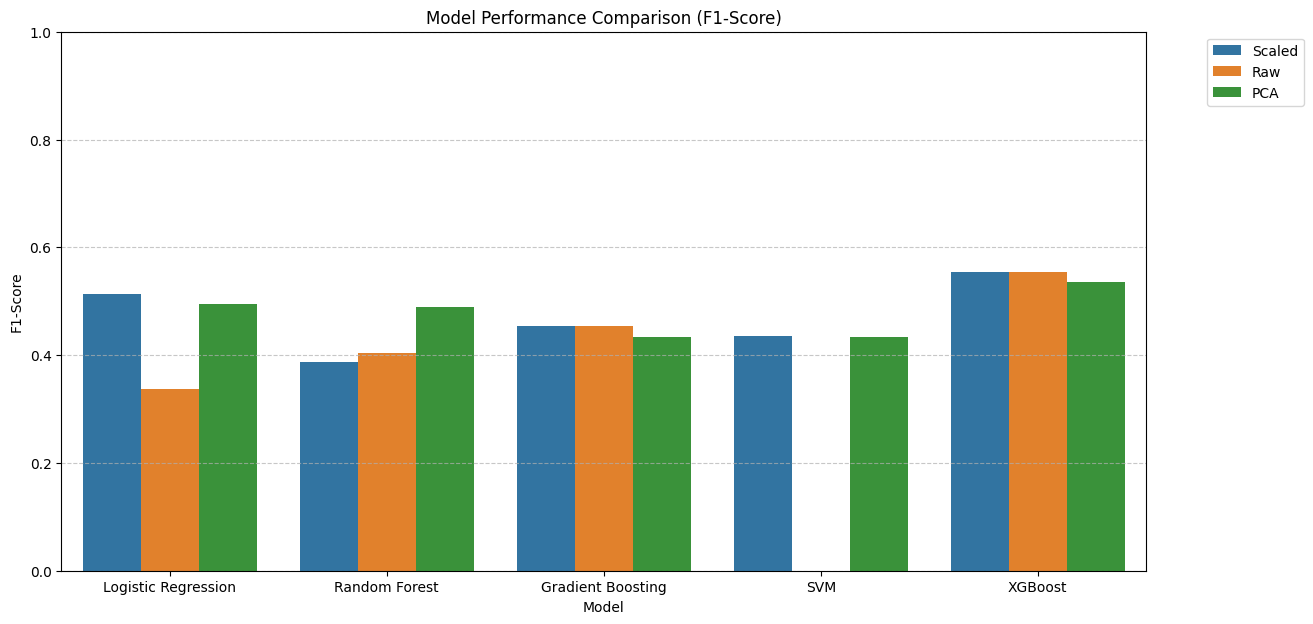

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.barplot(x='Model', y='F1-Score', hue='Dataset', data=results_df)
plt.title('Model Performance Comparison (F1-Score)')
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [32]:
print('Final Model Performance Comparison Table:')
display(results_df.sort_values(by=['F1-Score', 'ROC-AUC'], ascending=False))

Final Model Performance Comparison Table:


,Dataset,Model,Accuracy,F1-Score,ROC-AUC
4,Scaled,XGBoost,0.888393,0.553571,0.895483
9,Raw,XGBoost,0.888393,0.553571,0.895483
14,PCA,XGBoost,0.883929,0.535714,0.866808
0,Scaled,Logistic Regression,0.886161,0.514286,0.892506
10,PCA,Logistic Regression,0.886161,0.495050,0.894661
11,PCA,Random Forest,0.888393,0.489796,0.858405
2,Scaled,Gradient Boosting,0.881696,0.453608,0.903827
7,Raw,Gradient Boosting,0.881696,0.453608,0.903671
3,Scaled,SVM,0.883929,0.434783,0.882438
12,PCA,Gradient Boosting,0.866071,0.433962,0.878913


### Selection of Best Model and Dataset
Based on the evaluation metrics above, the selected configuration with the highest F1-Score is **XGBoost**

In [34]:
best_config = results_df.loc[results_df['F1-Score'].idxmax()]

print("BEST PERFORMANCE SUMMARY")
print(f"Best Model:   {best_config['Model']}")
print(f"Best Dataset: {best_config['Dataset']}")
print(f"F1-Score:     {best_config['F1-Score']:.4f}")
print(f"ROC-AUC:      {best_config['ROC-AUC']:.4f}")
print(f"Accuracy:     {best_config['Accuracy']:.4f}")

best_dataset_name = best_config['Dataset']
X_train_best, X_test_best = datasets[best_dataset_name]

BEST PERFORMANCE SUMMARY
Best Model:   XGBoost
Best Dataset: Scaled
F1-Score:     0.5536
ROC-AUC:      0.8955
Accuracy:     0.8884


### Export Results and Best Model
Saving the comparison metrics and the trained model for deployment or future reference.

In [35]:
import joblib
import os

results_csv_path = '/content/drive/MyDrive/Datasets/model_comparison_results.csv'
results_df.to_csv(results_csv_path, index=False)
print(f"Results table exported to: {results_csv_path}")

best_model_name = best_config['Model']
best_model_obj = models[best_model_name]

model_export_path = '/content/drive/MyDrive/Datasets/best_marketing_model.joblib'
joblib.dump(best_model_obj, model_export_path)

print(f"Best model ({best_model_name}) exported to: {model_export_path}")

Results table exported to: /content/drive/MyDrive/Datasets/model_comparison_results.csv
Best model (XGBoost) exported to: /content/drive/MyDrive/Datasets/best_marketing_model.joblib
